In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d
%matplotlib inline
from ipywidgets import interact, fixed
import ipywidgets as widgets
from numba import njit, prange
import pickle
from typing import List, Tuple, Callable, Any



from utils import MovingFunctionCalculator
from utils import Analytical
from utils import Plotter

In [2]:
@njit
def calc_propensities(grid:np.ndarray[Any, np.dtype[np.float64]], 
                      grid_factors:np.ndarray[Any, np.dtype[np.float64]],
                      kon, koff, kstep):
    
    n_on = np.sum(grid_factors)
    n_off = np.sum(grid)
    n_step = np.sum(grid)

    aon = n_on*kon
    aoff = n_off*koff
    astep = n_step*kstep

    return np.array([aon, aoff, astep])


@njit
def bind_kinesin(grid: np.ndarray[Any, np.dtype[np.float64]],
                 grid_factors:np.ndarray[Any, np.dtype[np.float64]]) -> None:
    
    S = np.cumsum(grid_factors)
    r = S[-1]*np.random.random()
    side = np.argmax(S>=r)
    grid[side] += 1

@njit
def unbind_kinesin(grid: np.ndarray[Any, np.dtype[np.float64]]) -> None:
    S = np.cumsum(grid)
    r = np.random.randint(low = 1, high = int(S[-1])+1)
    side = np.argmax(S>=r)

    grid[side] -= 1

@njit
def move_kinesin_w_fall(grid: np.ndarray[Any, np.dtype[np.float64]]) -> None:
    S = np.cumsum(grid)
    r = np.random.randint(low = 1, high = int(S[-1])+1)
    side = np.argmax(S>=r)
    # side=5

    grid[side] -= 1
    if side != len(grid)-1:
        grid[side+1] += 1


@njit
def step(grid, grid_factors, kon, koff, kstep)->Tuple[float, int]:
    r1 = np.random.uniform()
    r2 = np.random.uniform()

    A = calc_propensities(grid, grid_factors, kon, koff, kstep)
    R_tot = np.sum(A)
    
    A_normalised = np.cumsum(A)/R_tot

    dt = (1/R_tot) * np.log(1/r1)
    idx = np.argwhere(A_normalised>r2)[0][0]
    return dt, int(idx)


# @njit
# def calc_binding_grid_factors(grid, grid_factors, dt):
#     new_grid_factors=np.where(grid<=3, 0.5*np.tanh(grid)+1, 0)            
#     return new_grid_factors

# @njit
# def calc_binding_grid_factors(grid, grid_factors, dt): # Identity operator
#     return grid_factors

@njit
def simulation(L, T, kon, koff, kstep, calc_binding_grid_factors:Callable[[np.ndarray, np.ndarray, float], np.ndarray]):
    time = 0.0
    block = 0
    period = 0.1
    next_write_time = period
    blocks = int(T/period)

    grid:np.ndarray[Any, np.dtype[np.float64]] = np.ones(L)
    grid_factors = np.ones(L,dtype=np.float64 )

    DATA = np.zeros((blocks, L))
    TIMES= np.zeros(blocks)

    while time<T:
        dt, idx = step(grid, grid_factors, kon, koff, kstep)
        time+= dt      

        # Action
        if idx==0:
            bind_kinesin(grid, grid_factors)
        elif idx==1:
            unbind_kinesin(grid)
        else:
            move_kinesin_w_fall(grid)
        
        
        #Update grid_factors
        grid_factors = calc_binding_grid_factors(grid, grid_factors, dt)


        #Write    
        if next_write_time<time:
            DATA[block,:] = grid
            TIMES[block] = time
            block+=1
            next_write_time+=period

    return DATA[:block], TIMES[:block]

@njit(parallel=True)
def multiple_SIMS_last(num, L, T, kon, koff, kstep, 
                       calc_binding_grid_factors:Callable[[np.ndarray, np.ndarray, float], np.ndarray]):

    LAST_FRAMES = np.zeros((num, L))
    for i in prange(num):
        DATA, TIMES = simulation(L, T, kon, koff, kstep, calc_binding_grid_factors)
        LAST_FRAMES[i,:]=DATA[-1,:]
    return LAST_FRAMES

In [3]:
class CalcBindingFactors:
    @staticmethod    
    @njit
    def identity(grid, grid_factors, dt): # Identity operator
        return grid_factors


    @staticmethod    
    @njit
    def tanh(grid, grid_factors, dt): 
        return np.where(grid<=3, 0.5*np.tanh(grid)+1, 0) 
    
    
    @staticmethod    
    @njit
    def exp(grid, grid_factors, dt): 
        alpha = 1
        -dt*alpha*(grid_factors-np.ones(L))
    

    @staticmethod    
    @njit
    def quadratic(grid, grid_factors, dt): 
        x = np.linspace(-1,1,10) # 10 sides kernel
        m=1
        plateau=1.5
        kernel = 0.5*m*x**2
        y = np.convolve(grid, kernel)
        return np.maximum(np.minimum(y, plateau), 1)



In [4]:
L = 300
T = 20
kon = 0.8*np.exp(1)
koff = 0.8
kstep = 10

In [10]:
data, times = simulation(L, T, kon, koff, kstep, CalcBindingFactors.quadratic)

In [11]:
newframes = multiple_SIMS_last(20, L, T, kon, koff, kstep, CalcBindingFactors.quadratic)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [ ]:
sims = len(newframes)
avg_over_sims = np.mean(newframes, axis=0)

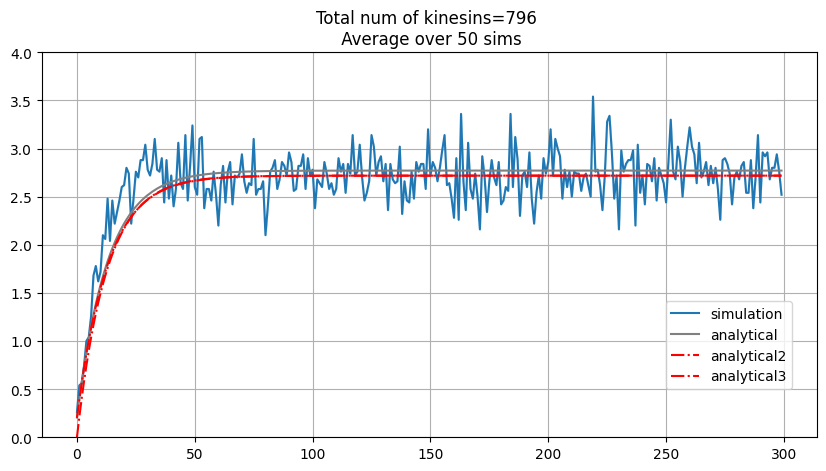

In [17]:
Plotter.frame(avg_over_sims, kon, koff, kstep, sims)

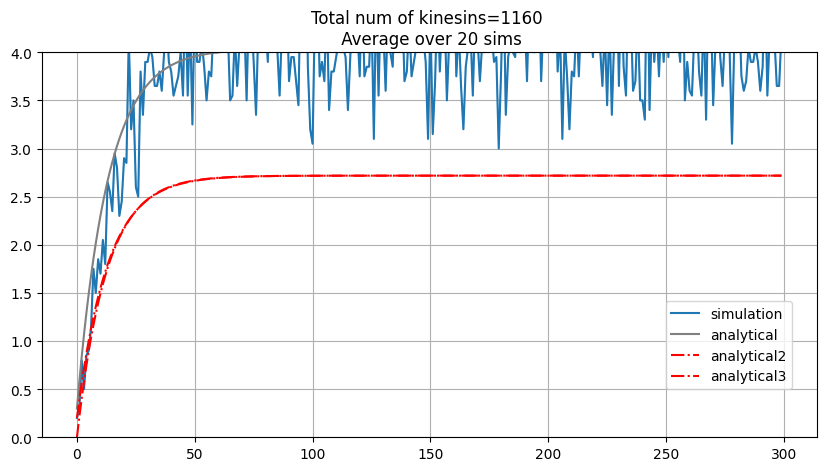

In [11]:
Plotter.frame(avg_over_sims, kon, koff, kstep, sims)

In [ ]:
grid = np.array([0,1,1,0,3,2,4,2])